# 03 - Training

**Thesis**: Multimodal Explainable AI for Breast Histopathology Classification  
**Experiment**: Train ConvNeXt-Base and Swin-Base on 3 stain normalization variants

---

This notebook covers:
1. **Training setup** - Loss function, optimizer, scheduler
2. **Ablation study** - 6 training runs (2 models x 3 stain methods)
3. **Learning curves** - Visualize training dynamics
4. **Results comparison** - Which model + stain method works best?

In [5]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

sys.path.insert(0, os.path.abspath("."))
from src.config import *
from src.models import get_model, get_parameter_groups, count_parameters
from src.dataset import create_dataloaders
from src.trainer import Trainer, create_criterion

# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Device: cuda
GPU: AMD Radeon RX 6800 XT


## 1. Training Setup

### The Ablation Study Design

We train **6 models** total:

| Run | Model | Stain Method | Experiment Name |
|-----|-------|-------------|-----------------|
| 1 | ConvNeXt-Base | None (baseline) | `convnext_none` |
| 2 | ConvNeXt-Base | Macenko | `convnext_macenko` |
| 3 | ConvNeXt-Base | Reinhard | `convnext_reinhard` |
| 4 | Swin-Base | None (baseline) | `swin_none` |
| 5 | Swin-Base | Macenko | `swin_macenko` |
| 6 | Swin-Base | Reinhard | `swin_reinhard` |

**Why this design?** By keeping everything else constant (same split, same augmentation, same hyperparameters) and only varying the model and stain method, we can isolate:
1. **Model effect**: ConvNeXt vs Swin (averaging across stain methods)
2. **Stain effect**: None vs Macenko vs Reinhard (averaging across models)
3. **Interaction**: Does stain normalization help one model more than the other?

### Hyperparameters

| Parameter | Value | Why |
|---|---|---|
| Optimizer | AdamW | Standard for transformers, works well for CNNs too |
| Backbone LR | 1e-5 | Gentle fine-tuning of pretrained features |
| Head LR | 1e-3 | Fast learning for randomly-initialized classifier |
| Weight decay | 1e-4 | L2 regularization to prevent overfitting |
| Scheduler | Cosine Annealing | Smoothly decreases LR, proven to improve convergence |
| Batch size | 16 | Safe for 16GB VRAM with both models |
| Label smoothing | 0.1 | Prevents overconfidence |
| Early stopping | 15 epochs | Stops when validation F1 plateaus |
| Max epochs | 100 | Upper bound (early stopping usually triggers earlier) |

In [14]:
# 1.1 Define the training function for a single experiment

def run_experiment(model_name, stain_method, max_epochs=MAX_EPOCHS, batch_size=16):
    """
    Run a single training experiment.
    
    Args:
        model_name: "convnext" or "swin"
        stain_method: "none", "macenko", or "reinhard"
        max_epochs: Maximum training epochs
        batch_size: Training batch size
    
    Returns:
        history dict and best validation F1
    """
    experiment_name = f"{model_name}_{stain_method}"
    
    # Check if already trained
    checkpoint_path = os.path.join(WEIGHTS_DIR, experiment_name, "best_model.pth")
    if os.path.exists(checkpoint_path):
        print(f"\n[{experiment_name}] Already trained. Loading results...")
        results_path = os.path.join(RESULTS_DIR, experiment_name, "training_history.csv")
        if os.path.exists(results_path):
            df = pd.read_csv(results_path)
            history = {col: df[col].tolist() for col in df.columns}
            best_f1 = max(history["val_f1"])
            print(f"  Best val F1: {best_f1:.4f}")
            return history, best_f1
    
    print(f"\n{'='*60}")
    print(f"Starting experiment: {experiment_name}")
    print(f"{'='*60}")
    
    # 1. Create DataLoaders
    train_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "train")
    val_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "val")
    test_dir = os.path.join(PROCESSED_DATA_DIR, stain_method, "test")
    
    train_loader, val_loader, _, class_weights = create_dataloaders(
        train_dir, val_dir, test_dir, batch_size=batch_size, num_workers=NUM_WORKERS
    )
    
    # 2. Create model
    model = get_model(model_name, num_classes=NUM_CLASSES, pretrained=True)
    total_params, _ = count_parameters(model)
    print(f"  Model: {model_name} ({total_params:,} params)")
    
    # 3. Create optimizer with discriminative learning rates
    param_groups = get_parameter_groups(model, backbone_lr=1e-5, head_lr=1e-3)
    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    
    # 4. Create loss function
    criterion = create_criterion(class_weights, label_smoothing=LABEL_SMOOTHING)
    
    # 5. Create scheduler
    scheduler = CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-7)
    
    # 6. Train!
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        device=DEVICE,
        experiment_name=experiment_name,
        patience=EARLY_STOPPING_PATIENCE,
    )
    
    history = trainer.fit(max_epochs=max_epochs)
    
    # Cleanup GPU memory
    del model, optimizer, criterion, trainer
    torch.cuda.empty_cache()
    
    return history, max(history["val_f1"])

print("Training function ready.")

Training function ready.


## 2. Run All Experiments

This cell runs all 6 experiments sequentially. On your RX 6800 XT, expect roughly:
- **~15-30 min per experiment** (depending on early stopping)
- **~1.5-3 hours total** for all 6 runs

Each experiment saves checkpoints and results automatically, so if interrupted you can re-run and it will skip completed experiments.

In [15]:
# 2.1 Run all 6 experiments
MODEL_NAMES = ["convnext", "swin"]
all_results = {}

total_start = time.time()

for model_name in MODEL_NAMES:
    for stain_method in STAIN_METHODS:
        experiment_name = f"{model_name}_{stain_method}"
        history, best_f1 = run_experiment(model_name, stain_method, batch_size=16)
        all_results[experiment_name] = {
            "history": history,
            "best_f1": best_f1,
        }

total_time = time.time() - total_start
print(f"\n{'='*60}")
print(f"All experiments complete! Total time: {total_time/60:.1f} minutes")
print(f"{'='*60}")

# Summary table
print(f"\n{'Experiment':<25} {'Best Val F1':>12} {'Best Epoch':>12} {'Total Epochs':>14}")
print("-" * 65)
for name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    print(f"{name:<25} {result['best_f1']:>12.4f} {h['epoch'][best_idx]:>12} {len(h['epoch']):>14}")


[convnext_none] Already trained. Loading results...
  Best val F1: 0.8480

Starting experiment: convnext_macenko


  Model: convnext (87,574,664 params)

Training: convnext_macenko
  Device: cuda
  Max epochs: 100
  Early stopping patience: 15
  Train batches: 73
  Val batches: 16



/home/abdullah/Documents/GitHub/Personal/densnet-thesis/venvs/torch-rocm/lib64/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch   1/100 | Train Loss: 2.0802 Acc: 0.1507 F1: 0.1238 | Val Loss: 3.2656 Acc: 0.0593 F1: 0.0197 | LR: 1.00e-05
  ** New best val F1: 0.0197 - model saved **
Epoch   2/100 | Train Loss: 2.0251 Acc: 0.1216 F1: 0.0929 | Val Loss: 2.9326 Acc: 0.0632 F1: 0.0149 | LR: 9.99e-06
Epoch   3/100 | Train Loss: 2.0013 Acc: 0.1378 F1: 0.1007 | Val Loss: 3.0093 Acc: 0.0632 F1: 0.0149 | LR: 9.98e-06
Epoch   4/100 | Train Loss: 1.9939 Acc: 0.1224 F1: 0.0807 | Val Loss: 3.0198 Acc: 0.0553 F1: 0.0131 | LR: 9.96e-06
Epoch   5/100 | Train Loss: 1.9963 Acc: 0.1267 F1: 0.0753 | Val Loss: 2.9561 Acc: 0.0711 F1: 0.0166 | LR: 9.94e-06
Epoch   6/100 | Train Loss: 1.9879 Acc: 0.1344 F1: 0.0853 | Val Loss: 2.9670 Acc: 0.0553 F1: 0.0131 | LR: 9.91e-06
Epoch   7/100 | Train Loss: 1.9888 Acc: 0.1336 F1: 0.0861 | Val Loss: 3.0282 Acc: 0.0553 F1: 0.0131 | LR: 9.88e-06
Epoch   8/100 | Train Loss: 1.9818 Acc: 0.1310 F1: 0.0526 | Val Loss: 2.9641 Acc: 0.0632 F1: 0.0149 | LR: 9.84e-06
Epoch   9/100 | Train Loss: 1.9830

## 3. Learning Curves

Learning curves show how loss and accuracy evolve during training. They reveal:
- **Overfitting**: Train loss keeps decreasing but val loss increases (gap widens)
- **Underfitting**: Both losses are high and flat (model can't learn)
- **Good fit**: Both losses decrease together, then val loss plateaus

We plot all 6 experiments for comparison.

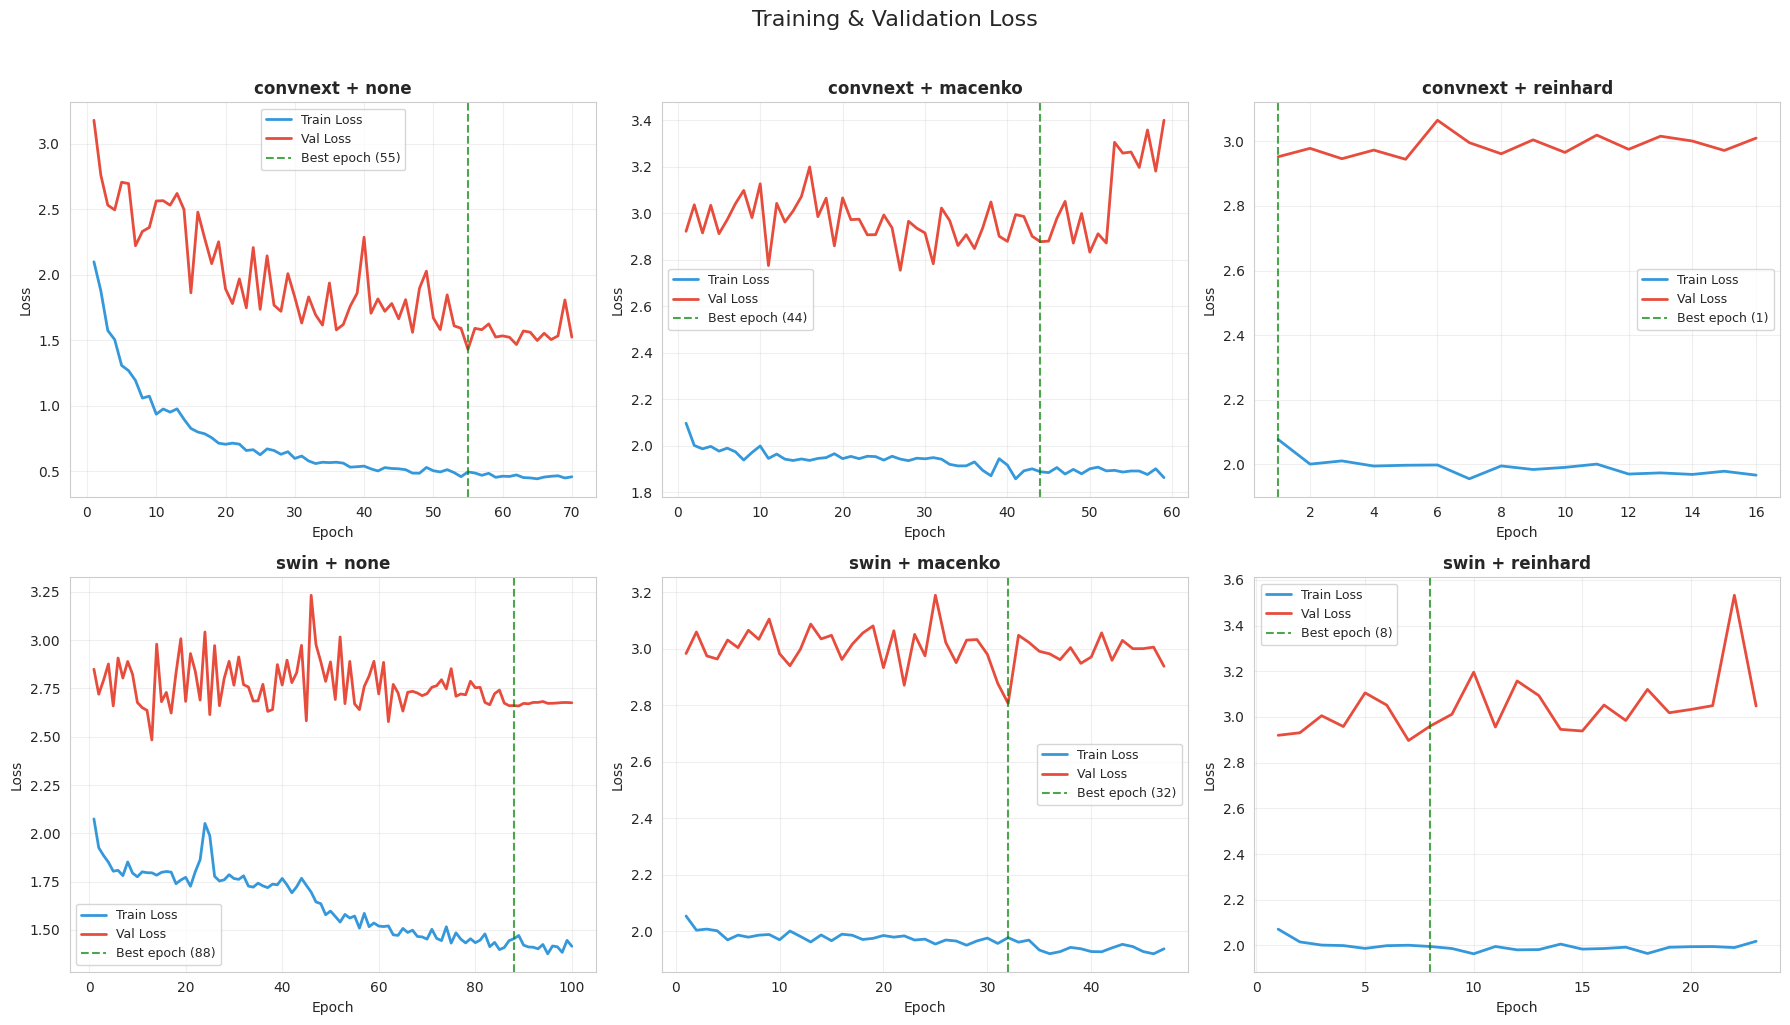

In [4]:
# 3.1 Loss curves - all experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axvline(x=h["epoch"][best_idx], color="green", linestyle="--", alpha=0.7, label=f"Best epoch ({h['epoch'][best_idx]})")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_loss.png"), dpi=150, bbox_inches="tight")
plt.show()

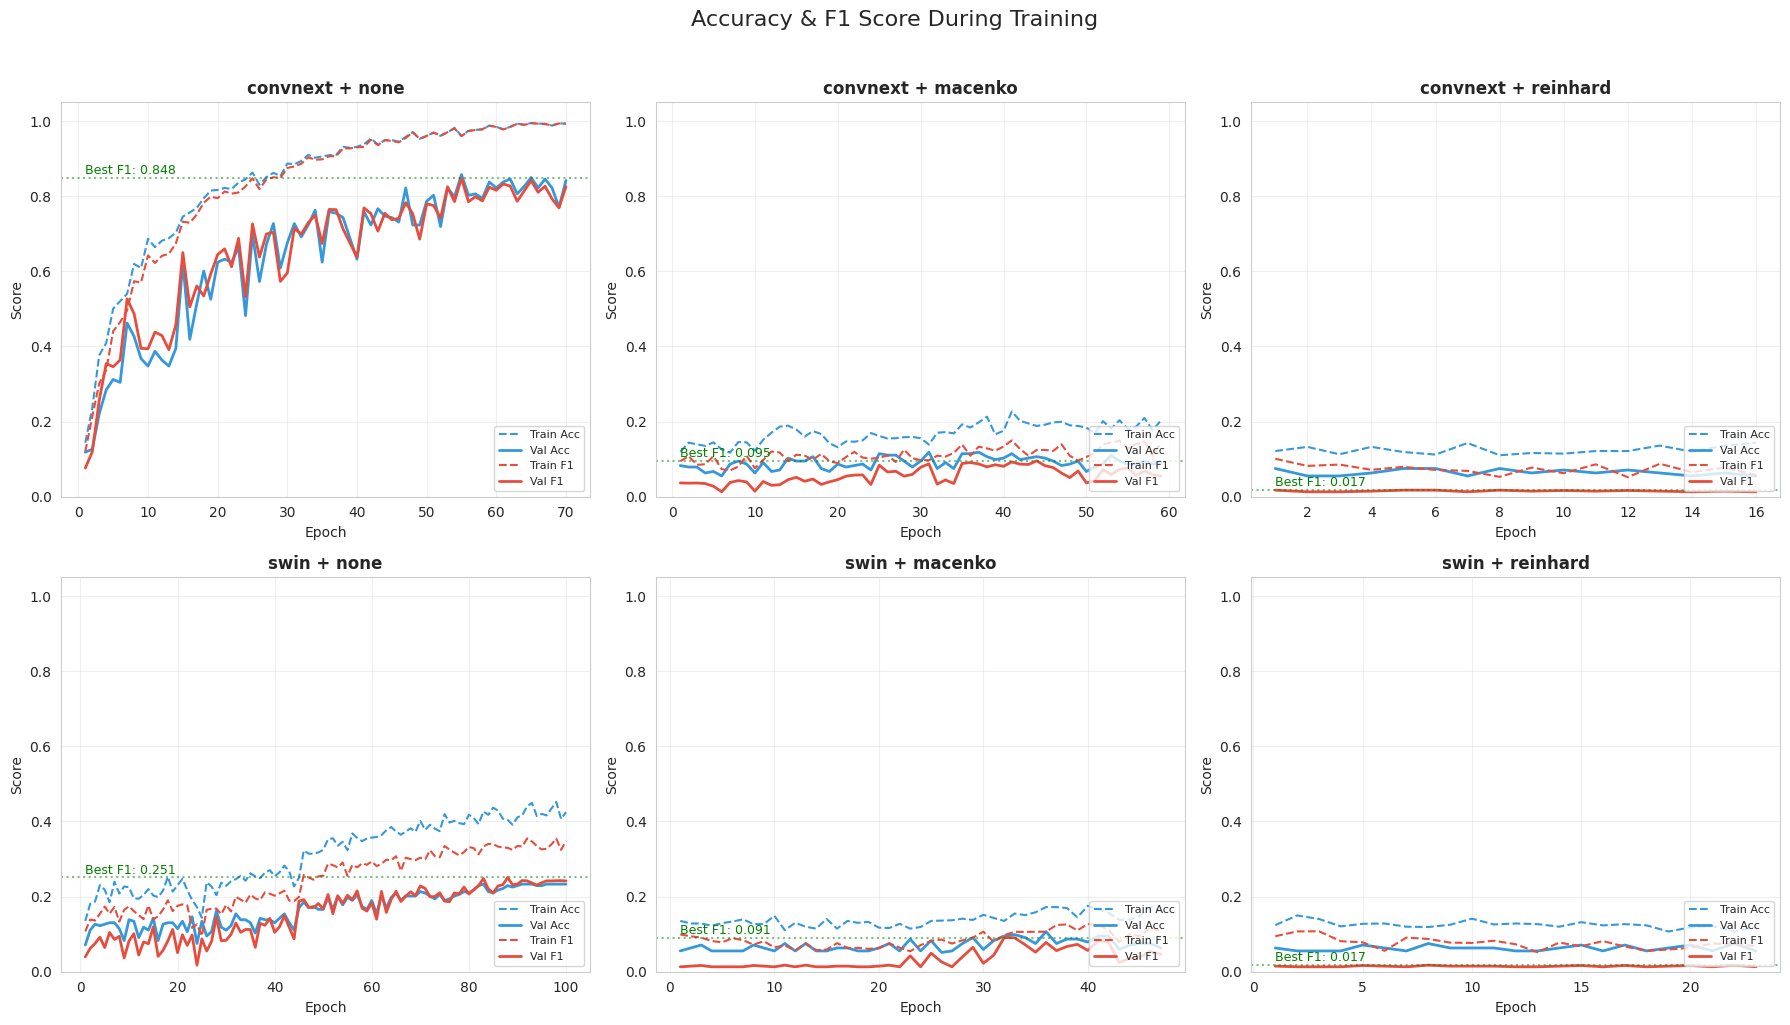

In [ ]:
# 3.2 Accuracy and F1 curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, stain_method in enumerate(STAIN_METHODS):
    for row, model_name in enumerate(MODEL_NAMES):
        ax = axes[row, col]
        exp_name = f"{model_name}_{stain_method}"
        h = all_results[exp_name]["history"]
        
        ax.plot(h["epoch"], h["train_acc"], label="Train Acc", color="#3498db", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_acc"], label="Val Acc", color="#3498db", linewidth=2)
        ax.plot(h["epoch"], h["train_f1"], label="Train F1", color="#e74c3c", linewidth=1.5, linestyle="--")
        ax.plot(h["epoch"], h["val_f1"], label="Val F1", color="#e74c3c", linewidth=2)
        
        best_idx = int(np.argmax(h["val_f1"]))
        ax.axhline(y=h["val_f1"][best_idx], color="green", linestyle=":", alpha=0.5)
        ax.text(1, h["val_f1"][best_idx] + 0.01, f"Best F1: {h['val_f1'][best_idx]:.3f}", fontsize=9, color="green")
        
        ax.set_title(f"{model_name} + {stain_method}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3)
        

plt.suptitle("Accuracy & F1 Score During Training", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "learning_curves_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

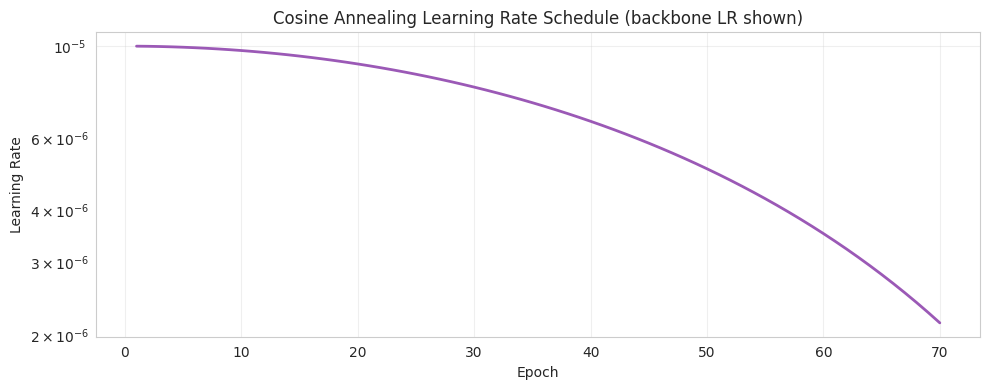

In [10]:
# 3.3 Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 4))

# Just show one experiment's LR curve (they're all the same schedule)
first_exp = list(all_results.keys())[0]
h = all_results[first_exp]["history"]
ax.plot(h["epoch"], h["lr"], color="#9b59b6", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Cosine Annealing Learning Rate Schedule (backbone LR shown)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lr_schedule.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Results Comparison

### Key questions we're answering:
1. **Model comparison**: Is ConvNeXt or Swin better for histopathology?
2. **Stain normalization impact**: Does Macenko/Reinhard help, hurt, or not matter?
3. **Best combination**: Which model + stain method should we use going forward?

In [11]:
# 4.1 Best validation F1 comparison
results_summary = []
for exp_name, result in all_results.items():
    h = result["history"]
    best_idx = int(np.argmax(h["val_f1"]))
    model_name, stain = exp_name.split("_", 1)
    results_summary.append({
        "Model": model_name,
        "Stain Method": stain,
        "Best Val F1": h["val_f1"][best_idx],
        "Best Val Acc": h["val_acc"][best_idx],
        "Best Epoch": h["epoch"][best_idx],
        "Total Epochs": len(h["epoch"]),
        "Final Train Loss": h["train_loss"][-1],
        "Final Val Loss": h["val_loss"][-1],
    })

df_results = pd.DataFrame(results_summary)
df_results = df_results.sort_values("Best Val F1", ascending=False).reset_index(drop=True)
print("\nResults ranked by Best Validation F1:\n")
print(df_results.to_string(index=False))

# Save
df_results.to_csv(os.path.join(RESULTS_DIR, "ablation_study_results.csv"), index=False)


Results ranked by Best Validation F1:

   Model Stain Method  Best Val F1  Best Val Acc  Best Epoch  Total Epochs  Final Train Loss  Final Val Loss
convnext         none     0.847950      0.857708          55            70          0.458085        1.523944
    swin         none     0.250939      0.229249          88           100          1.415448        2.676027
convnext      macenko     0.095432      0.106719          44            59          1.863883        3.400459
    swin      macenko     0.090897      0.094862          32            47          1.937799        2.938533
convnext     reinhard     0.017463      0.075099           1            16          1.966751        3.009979
    swin     reinhard     0.017463      0.075099           8            23          2.018339        3.047767


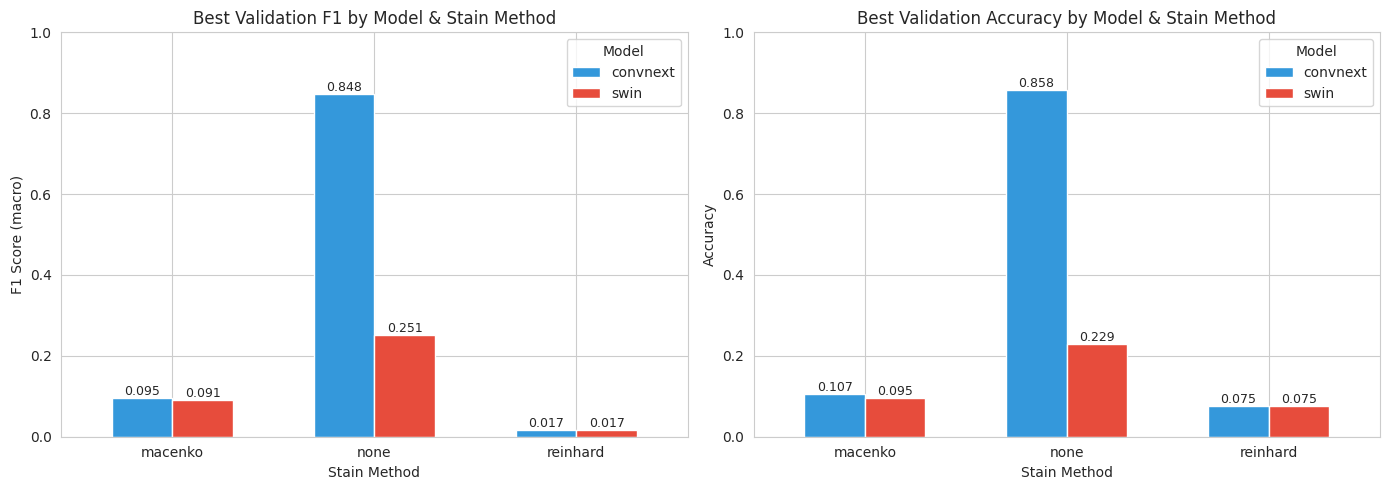

In [12]:
# 4.2 Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by model and stain method
pivot_f1 = df_results.pivot(index="Stain Method", columns="Model", values="Best Val F1")
pivot_f1.plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"], width=0.6)
axes[0].set_title("Best Validation F1 by Model & Stain Method")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Model")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=9)

# Accuracy comparison
pivot_acc = df_results.pivot(index="Stain Method", columns="Model", values="Best Val Acc")
pivot_acc.plot(kind="bar", ax=axes[1], color=["#3498db", "#e74c3c"], width=0.6)
axes[1].set_title("Best Validation Accuracy by Model & Stain Method")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Model")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "ablation_study_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# 4.3 Analyze effects

# Model effect (averaging across stain methods)
print("MODEL EFFECT (averaged across stain methods):")
for model in ["convnext", "swin"]:
    mask = df_results["Model"] == model
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {model:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Stain effect (averaging across models)
print("\nSTAIN NORMALIZATION EFFECT (averaged across models):")
for stain in STAIN_METHODS:
    mask = df_results["Stain Method"] == stain
    avg_f1 = df_results[mask]["Best Val F1"].mean()
    avg_acc = df_results[mask]["Best Val Acc"].mean()
    print(f"  {stain:<12s} Avg F1: {avg_f1:.4f}  Avg Acc: {avg_acc:.4f}")

# Best overall
best_row = df_results.iloc[0]
print(f"\nBEST COMBINATION: {best_row['Model']} + {best_row['Stain Method']}")
print(f"  F1: {best_row['Best Val F1']:.4f}  Acc: {best_row['Best Val Acc']:.4f}  (epoch {int(best_row['Best Epoch'])})")

MODEL EFFECT (averaged across stain methods):
  convnext     Avg F1: 0.3203  Avg Acc: 0.3465
  swin         Avg F1: 0.1198  Avg Acc: 0.1331

STAIN NORMALIZATION EFFECT (averaged across models):
  none         Avg F1: 0.5494  Avg Acc: 0.5435
  macenko      Avg F1: 0.0932  Avg Acc: 0.1008
  reinhard     Avg F1: 0.0175  Avg Acc: 0.0751

BEST COMBINATION: convnext + none
  F1: 0.8480  Acc: 0.8577  (epoch 55)


## Summary

### What we trained:
- **6 models**: 2 architectures (ConvNeXt, Swin) x 3 stain methods (none, macenko, reinhard)
- All with identical hyperparameters for a fair comparison

### Key outputs saved:
- **Model checkpoints**: `weights/{experiment_name}/best_model.pth` - used in notebooks 04 and 05
- **Training histories**: `results/{experiment_name}/training_history.csv` - the learning curves
- **Ablation results**: `results/ablation_study_results.csv` - the summary table

### What happens next:
- **Notebook 04** (Evaluation): Load the best checkpoint for each experiment and evaluate on the held-out **test set** (which the model has never seen)
- **Notebook 05** (Explainability): Generate XAI explanations and evaluate them quantitatively